In [21]:
import numpy as np
import pandas as pd
import sys
sys.path.append('/Users/jake/sbx/paragon/lib')
sys.path.append('.')

import math
from datetime import datetime, timedelta, date

stocks = ['AAPL', 'ALTM', 'AMAT', 'AMZN', 'BA', 'BAC', 'BK', 'BMY', 'BSX', 'CLF', 'CNC', 'CRWD', 'DIS', 'EA', 'EOG', 'FCX', 'FFXDF', 'FSLR', 'GILD', 'GOOGL', 'HAL', 'HSY', 'JPM', 'LLY', 'MDB', 'META', 'MP', 'MSFT', 'NEM', 'NVDA', 'NXPI', 'PCG', 'PWR', 'QCOM', 'RTX', 'SHEL', 'SLV', 'UBER', 'WMT', 'XBI']
# stocks = ['IWF', 'MTUM', 'USMV', 'VYM', 'IWD', 'IJR']
# stocks = ['AAL', 'ADBE', 'AMD', 'BABA', 'C', 'AMZN', 'GOOGL', 'MSFT', 'SPCE', 'AAPL', 'FB', 'IPO', 'ARKK', 'TSLA', 'SLV']

num_days = 250

start_date = date.today() - timedelta(days = math.ceil((num_days/(5/7))))



In [22]:
from polygon import RESTClient
from dateutil import tz
def aggregates_to_df(resp):
    epoch = datetime(1601, 1, 1)
    df = pd.DataFrame(resp.results)
#     print(str(df))
#     tz_ = tz.gettz('America/New_York')
    tz_ = tz.gettz('UTC')

    df.set_index(df['t'].apply(lambda x: datetime.fromtimestamp(x / 1000, tz=tz_)), inplace=True)
    df.rename(columns={"v": "volume", "o": "open", "c": "close", "h": "high", "l": "low"}, inplace=True)
    if 't' in df:
        df.drop(['t'], axis=1, inplace=True)
    if 'n' in df:
        df.drop(['n'], axis=1, inplace=True)

    df.index.name = None
#     print(str(df.index))
    return df

def history(symbol, start_date, timespan = 'day'):
    date_format = "%Y-%m-%d"
    
    end_date = date.today() + timedelta(days = 7) # Polygon is exclusive on dates and must extend for a week
    client = RESTClient('WeYC_RTF_nZg3S_UKGI68lvNZ__8l6YM09p_Rg')
    multiplier = 1

    try:
        resp = client.stocks_equities_aggregates(symbol, multiplier, timespan, start_date.strftime(date_format), end_date.strftime(date_format))
    except Exception as e:
        print("[history_aggregate()]: Polygon connection error: %s" % (str(e)))

    if resp.status != 'OK':
        raise ValueError("Polygon history_aggregate response not OK: %s" % (resp['status']))
        
    if resp.results == None or len(resp.results) == 0:
        raise ValueError("Polygon history_aggregate results are empty")
        
    df = aggregates_to_df(resp)
    
    return df



In [23]:
# Pull Data

ohlcvs = {}
for stock in stocks:
    print("%s" % (stock))
    ohlcv = history(stock, start_date)
    ohlcvs[stock] = ohlcv['close']
    
df = pd.DataFrame(ohlcvs)
# print(str(df))

    

AAPL
ALTM
AMAT
AMZN
BA
BAC
BK
BMY
BSX
CLF
CNC
CRWD
DIS
EA
EOG
FCX
FFXDF
FSLR
GILD
GOOGL
HAL
HSY
JPM
LLY
MDB
META
MP
MSFT
NEM
NVDA
NXPI
PCG
PWR
QCOM
RTX
SHEL
SLV
UBER
WMT
XBI


# HRP

In [24]:
from mlfinlab.portfolio_optimization.hrp import HierarchicalRiskParity
from IPython.core.debugger import Pdb
from scipy.cluster.hierarchy import dendrogram
hrp = HierarchicalRiskParity()

res = hrp.allocate(np.array(df.columns.tolist()), df, linkage='ward')

weights = hrp.weights.T
weights.columns = ['weight']
print(weights.index.tolist())


Optimal Ordering!
['FFXDF', 'WMT', 'BSX', 'LLY', 'AAPL', 'GOOGL', 'MSFT', 'AMZN', 'META', 'CRWD', 'MDB', 'NXPI', 'QCOM', 'AMAT', 'NVDA', 'PWR', 'SHEL', 'EOG', 'HAL', 'DIS', 'UBER', 'EA', 'BK', 'BAC', 'JPM', 'BA', 'FSLR', 'XBI', 'CLF', 'FCX', 'MP', 'ALTM', 'SLV', 'NEM', 'PCG', 'HSY', 'RTX', 'GILD', 'BMY', 'CNC']


In [25]:
import pprint
pp = pprint.PrettyPrinter(indent=4)

portfolio_size_all = 362000

portfolio_size = portfolio_size_all * 0.4
portfolio_size_all_weather = portfolio_size_all - portfolio_size

# for stock, weight in weights['weight'].sort_values(ascending=False).iteritems():
#     amount = portfolio_size * weight
 
#     print('{a}\t {b:5,.2f}%\t {c:10,.0f}'.format(a=stock, b=weight*100.0, c=amount))

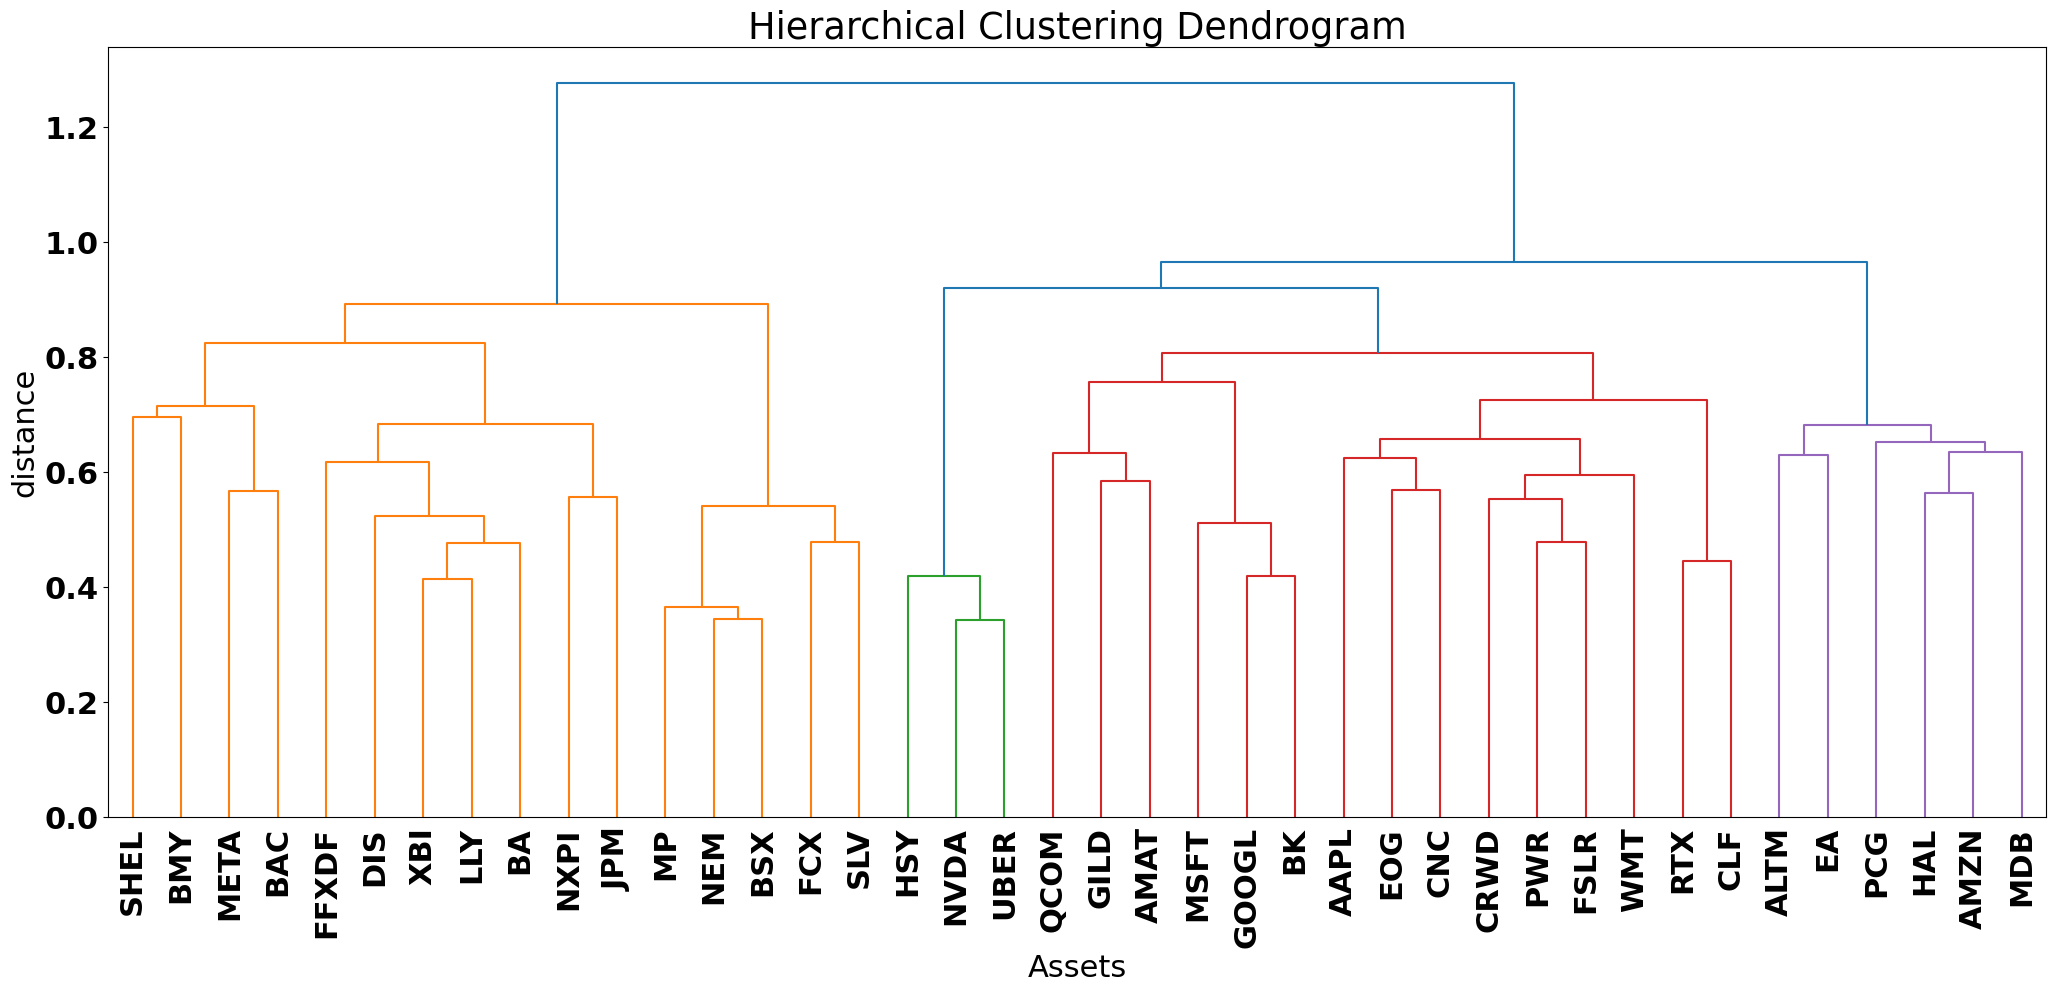

In [26]:
# calculate full dendrogram
from matplotlib import pyplot as plt
font = {#'family' : 'normal',
        'weight' : 'bold',
        'size'   : 22}
plt.rc('font', **font)
plt.figure(figsize=(25, 10))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Assets')
plt.ylabel('distance')
dendrogram(
    hrp.clusters,
    labels=weights.index.tolist(),
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=22.,  # font size for the x axis labels
)
plt.show()

In [27]:
# Before
for stock, weight in weights['weight'].sort_values(ascending=False).iteritems():
    amount = portfolio_size * weight
 
    print('{a}\t {b:5,.2f}%\t {c:10,.0f}'.format(a=stock, b=weight*100.0, c=amount))

RTX	  7.76%	     11,233
BSX	  6.88%	      9,967
WMT	  6.87%	      9,942
EA	  5.88%	      8,518
SHEL	  5.65%	      8,178
HSY	  5.51%	      7,986
FFXDF	  5.10%	      7,389
PCG	  4.58%	      6,630
BK	  4.47%	      6,474
GILD	  3.48%	      5,043
AAPL	  3.31%	      4,794
MSFT	  3.23%	      4,672
EOG	  2.95%	      4,266
SLV	  2.48%	      3,595
BMY	  2.20%	      3,192
JPM	  2.13%	      3,082
CNC	  2.03%	      2,942
XBI	  1.97%	      2,854
LLY	  1.95%	      2,823
DIS	  1.75%	      2,539
HAL	  1.70%	      2,468
PWR	  1.67%	      2,421
GOOGL	  1.66%	      2,397
AMZN	  1.60%	      2,317
BAC	  1.52%	      2,198
BA	  1.49%	      2,156
NEM	  1.42%	      2,050
NXPI	  1.35%	      1,958
UBER	  1.22%	      1,772
QCOM	  0.84%	      1,220
FCX	  0.75%	      1,084
CLF	  0.75%	      1,082
MP	  0.67%	        969
META	  0.66%	        949
FSLR	  0.59%	        850
MDB	  0.56%	        804
AMAT	  0.41%	        589
CRWD	  0.39%	        570
ALTM	  0.31%	        442
NVDA	  0.26%	        383


/var/folders/05/6qtdk7l95g5_bf0y9z2srtkr0000gp/T/ipykernel_93477/1399938178.py:2: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  for stock, weight in weights['weight'].sort_values(ascending=False).iteritems():


In [12]:
# All Weather Ratios
all_weather = {
    'VTI': 0.3,
    'TLT': 0.4,
    'IEI': 0.15,
    'DBC': 0.075,
    'GLD': 0.075
}

for symbol in all_weather:
    amount = all_weather[symbol] * portfolio_size_all_weather
    print('{a}\t {b:5,.2f}%\t {c:10,.0f}'.format(a=symbol, b=all_weather[symbol]*100.0, c=amount))


VTI	 30.00%	     65,160
TLT	 40.00%	     86,880
IEI	 15.00%	     32,580
DBC	  7.50%	     16,290
GLD	  7.50%	     16,290


In [13]:
def print_clusters(timeSeries, Z, k, plot=False, plot_threshold=5):
    # k Number of clusters I'd like to extract
    results = fcluster(Z, k, criterion='maxclust')
    
    # check the results
    s = pd.Series(results)
    
    clusters = s.unique()

    for c in clusters:
        cluster_indeces = s[s==c].index
#         print(str(cluster_indeces))
        cluster_size = len(cluster_indeces)
        print("Cluster %d number of entries %d" % (c, cluster_size))
        if plot and cluster_size > plot_threshold:
            cluster_series = timeSeries.T.iloc[:,cluster_indeces]
#             print(str(cluster_indeces))
#             print(str(len(cluster_series.T)))
#             cluster_series.plot(legend=False)
            sns.tsplot(data=cluster_series.T.values, err_style="unit_traces")
            plt.show()

In [43]:
cluster_series  = (cluster_series / cluster_series.iloc[0, :]) - 1

number_of_clusters_to_use = [20, ]
for k in number_of_clusters_to_use:
    print_clusters(cluster_series.T, Z, k, plot=True)

NameError: name 'cluster_series' is not defined